# Global Land Temperatures — Phase 2: Algorithm Implementation & Fine-Tuning
**Big Data Analytics | Group Project — Phase 2**

**Dataset:** GlobalLandTemperaturesByCity.csv (Berkeley Earth, ~8.6M rows)  
**Algorithms:** Linear Regression (Prediction) + K-Means Clustering  
**License:** CC BY-NC-SA 4.0

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Feature Engineering](#2)
3. [Algorithm 1 — Linear Regression (Prediction)](#3)
4. [Fine-Tuning — Polynomial & Ridge Regression](#4)
5. [Algorithm 2 — K-Means Clustering](#5)
6. [Fine-Tuning — Elbow & Silhouette Analysis](#6)
7. [Visualizations](#7)
8. [Model Summary & Export](#8)

## 1. Setup & Data Loading <a id='1'></a>

In [23]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH    = '/content/drive/MyDrive/GlobalLandTemperaturesByCity.csv'
CLEAN_PATH   = '/content/drive/MyDrive/GlobalLandTemp_cleaned.csv'
EXPORT_DIR   = '/content/drive/MyDrive/'

print('✅ Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats

from sklearn.linear_model  import LinearRegression, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.cluster       import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics       import mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.facecolor': '#F8FAFF', 'figure.facecolor': 'white',
})
print('✅ Libraries loaded.')

✅ Libraries loaded.


In [25]:
import os
if os.path.exists(CLEAN_PATH):
    print('Loading cleaned dataset from Phase 1...')
    df = pd.read_csv(CLEAN_PATH, parse_dates=['dt'])
else:
    print('Loading raw dataset (~60 seconds)...')
    df = pd.read_csv(FILE_PATH)
    df.columns = ['dt','Avg_Temp_C','Temp_Uncertainty_C','City','Country','Latitude','Longitude']
    df['dt']    = pd.to_datetime(df['dt'])
    df['Year']  = df['dt'].dt.year
    df['Month'] = df['dt'].dt.month
    df['Decade']= (df['Year'] // 10) * 10
    df = df.dropna(subset=['Avg_Temp_C'])

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Year range: {df["Year"].min()} - {df["Year"].max()}')
df.head(3)

Loading cleaned dataset from Phase 1...
Shape: 8,235,082 rows x 12 cols
Year range: 1743 - 2013


,dt,Year,Month,Month_Name,Season,Decade,City,Country,Latitude,Longitude,Avg_Temp_C,Temp_Uncertainty_C
0,1743-11-01,1743,11,Nov,SON (Autumn),1740,Århus,Denmark,57.05N,10.33E,6.068,1.737
1,1744-04-01,1744,4,Apr,MAM (Spring),1740,Århus,Denmark,57.05N,10.33E,5.788,3.624
2,1744-05-01,1744,5,May,MAM (Spring),1740,Århus,Denmark,57.05N,10.33E,10.644,1.283


## 2. Feature Engineering <a id='2'></a>

In [26]:
# ── Annual city-level aggregation ─────────────────────────────────────────────
# One row per city per year — used for regression
city_yr = (
    df.groupby(['City','Country','Year'])
    .agg(Avg_Temp_C=('Avg_Temp_C','mean'))
    .reset_index()
)
print(f'city_yr shape: {city_yr.shape}')
city_yr.head()

city_yr shape: (689527, 4)


,City,Country,Year,Avg_Temp_C
0,A Coruña,Spain,1743,10.779000
1,A Coruña,Spain,1744,13.678125
2,A Coruña,Spain,1745,9.170500
3,A Coruña,Spain,1750,13.489273
4,A Coruña,Spain,1751,13.698500


In [27]:
# ── City profile features for clustering ─────────────────────────────────────
# One row per city: mean temp, seasonality amplitude, warming rate

# Mean annual temperature
mean_temp = df.groupby(['City','Country'])['Avg_Temp_C'].mean().rename('Mean_Temp')

# Seasonality amplitude: max monthly mean - min monthly mean
monthly_city = df.groupby(['City','Country','Month'])['Avg_Temp_C'].mean().reset_index()
seasonality  = (
    monthly_city.groupby(['City','Country'])['Avg_Temp_C']
    .agg(lambda x: x.max() - x.min())
    .rename('Seasonality')
)

# Warming rate: slope of annual mean temperature vs year (post-1900)
def warming_rate(grp):
    g = grp[grp['Year'] >= 1900]
    if len(g) < 20: return np.nan
    slope, _, _, _, _ = stats.linregress(g['Year'], g['Avg_Temp_C'])
    return slope

warm_rate = city_yr.groupby(['City','Country']).apply(warming_rate).rename('Warming_Rate')

# Combine
city_profiles = pd.concat([mean_temp, seasonality, warm_rate], axis=1).dropna().reset_index()
print(f'City profiles shape: {city_profiles.shape}')
print(city_profiles.describe().round(3))

City profiles shape: (3490, 5)
       Mean_Temp  Seasonality  Warming_Rate
count   3490.000     3490.000      3490.000
mean      17.599       15.199         0.010
std        7.715       10.062         0.003
min      -11.855        0.426         0.005
25%       11.320        6.002         0.008
50%       18.288       14.747         0.010
75%       25.166       22.732         0.011
max       29.153       46.626         0.020


## 3. Algorithm 1 — Linear Regression (Prediction) <a id='3'></a>

In [28]:
# ── Per-city Linear Regression ────────────────────────────────────────────────
# Demonstrate on 6 sample cities across climate zones

SAMPLE_CITIES = [
    ('Paris',       'France'),
    ('Mumbai',      'India'),
    ('Moscow',      'Russia'),
    ('Lagos',       'Nigeria'),
    ('Buenos Aires','Argentina'),
    ('Sydney',      'Australia'),
]

results = {}

for city, country in SAMPLE_CITIES:
    sub = city_yr[
        (city_yr['City']==city) & (city_yr['Country']==country) &
        (city_yr['Year'] >= 1900)
    ].dropna()
    if len(sub) < 20:
        continue

    X = sub[['Year']]
    y = sub['Avg_Temp_C']
    train_mask = sub['Year'] < 2000

    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X, y, cv=5, scoring='r2').mean()

    results[f'{city}, {country}'] = {
        'model': model, 'X': X, 'y': y, 'sub': sub,
        'RMSE': round(rmse,3), 'R2': round(r2,3), 'CV_R2': round(cv,3)
    }

# Print summary
print(f'{"City":<30} {"RMSE":>8} {"R2":>8} {"CV R2":>8}')
print('-'*55)
for city, m in results.items():
    print(f'{city:<30} {m["RMSE"]:>8.3f} {m["R2"]:>8.3f} {m["CV_R2"]:>8.3f}')

City                               RMSE       R2    CV R2
-------------------------------------------------------
Paris, France                     0.668   -1.237   -0.391
Moscow, Russia                    1.110   -2.638   -0.334
Lagos, Nigeria                    0.352   -1.681   -0.744
Sydney, Australia                 0.500   -3.270   -0.724


## 4. Fine-Tuning — Polynomial & Ridge Regression <a id='4'></a>

In [29]:
# ── Polynomial & Ridge comparison ─────────────────────────────────────────────
print(f'{"City":<25} {"Linear R2":>12} {"Poly R2":>10} {"Ridge R2":>10} {"Best":>10}')
print('-'*70)

best_models = {}

for city, country in SAMPLE_CITIES:
    sub = city_yr[
        (city_yr['City']==city) & (city_yr['Country']==country) &
        (city_yr['Year'] >= 1900)
    ].dropna()
    if len(sub) < 20: continue

    X = sub[['Year']]
    y = sub['Avg_Temp_C']

    # Linear
    lin_cv  = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2').mean()

    # Polynomial degree=2
    poly_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('reg',  LinearRegression())
    ])
    poly_cv = cross_val_score(poly_pipe, X, y, cv=5, scoring='r2').mean()

    # Ridge
    ridge     = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5)
    ridge_cv  = cross_val_score(ridge, X, y, cv=5, scoring='r2').mean()

    best = max([('Linear',lin_cv),('Poly',poly_cv),('Ridge',ridge_cv)], key=lambda x:x[1])
    best_models[f'{city}, {country}'] = best[0]

    print(f'{city+", "+country:<25} {lin_cv:>12.3f} {poly_cv:>10.3f} {ridge_cv:>10.3f} {best[0]:>10}')

print('\nBest model per city:', best_models)

City                         Linear R2    Poly R2   Ridge R2       Best
----------------------------------------------------------------------
Paris, France                   -0.391     -0.649     -0.391      Ridge
Moscow, Russia                  -0.334     -0.146     -0.334       Poly
Lagos, Nigeria                  -0.744     -2.846     -0.744     Linear
Sydney, Australia               -0.724     -0.091     -0.724       Poly

Best model per city: {'Paris, France': 'Ridge', 'Moscow, Russia': 'Poly', 'Lagos, Nigeria': 'Linear', 'Sydney, Australia': 'Poly'}


In [30]:
# ── Cross-validation box plots ────────────────────────────────────────────────
city_key = ('Paris', 'France')
sub = city_yr[
    (city_yr['City']==city_key[0]) & (city_yr['Country']==city_key[1]) &
    (city_yr['Year'] >= 1900)
].dropna()
X_p = sub[['Year']]
y_p = sub['Avg_Temp_C']

linear_scores = cross_val_score(LinearRegression(), X_p, y_p, cv=10, scoring='r2')
poly_pipe2    = Pipeline([('poly', PolynomialFeatures(2, include_bias=False)), ('reg', LinearRegression())])
poly_scores   = cross_val_score(poly_pipe2, X_p, y_p, cv=10, scoring='r2')
ridge2        = RidgeCV(alphas=[0.01,0.1,1,10], cv=5)
ridge_scores  = cross_val_score(ridge2, X_p, y_p, cv=10, scoring='r2')

print(f'Linear  — Mean CV R2: {linear_scores.mean():.3f} ± {linear_scores.std():.3f}')
print(f'Poly    — Mean CV R2: {poly_scores.mean():.3f} ± {poly_scores.std():.3f}')
print(f'Ridge   — Mean CV R2: {ridge_scores.mean():.3f} ± {ridge_scores.std():.3f}')

Linear  — Mean CV R2: -0.250 ± 0.335
Poly    — Mean CV R2: -0.215 ± 0.226
Ridge   — Mean CV R2: -0.250 ± 0.335


## 5. Algorithm 2 — K-Means Clustering <a id='5'></a>

In [31]:
# ── Scale features ────────────────────────────────────────────────────────────
features  = city_profiles[['Mean_Temp','Seasonality','Warming_Rate']]
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(features)

# ── Fit K-Means k=5 ───────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
city_profiles['Cluster'] = kmeans.fit_predict(X_scaled)

sil   = silhouette_score(X_scaled, city_profiles['Cluster'])
iner  = kmeans.inertia_

print(f'K-Means (k=5) Results:')
print(f'  Silhouette Score: {sil:.4f}  (>0.5 = good separation)')
print(f'  Inertia:          {iner:.2f}')
print()
print('Cluster sizes:')
print(city_profiles['Cluster'].value_counts().sort_index())

K-Means (k=5) Results:
  Silhouette Score: 0.3691  (>0.5 = good separation)
  Inertia:          2027.80

Cluster sizes:
Cluster
0     362
1    1023
2     867
3     639
4     599
Name: count, dtype: int64


In [32]:
# ── Cluster profile summary ───────────────────────────────────────────────────
cluster_summary = city_profiles.groupby('Cluster')[['Mean_Temp','Seasonality','Warming_Rate']].mean().round(3)
cluster_labels  = {0:'Equatorial',1:'Tropical',2:'Temperate',3:'Continental',4:'Subarctic'}

# Sort clusters by Mean_Temp descending to assign labels
order = cluster_summary['Mean_Temp'].sort_values(ascending=False).index.tolist()
label_map = {cid: list(cluster_labels.values())[i] for i, cid in enumerate(order)}
city_profiles['Climate_Zone'] = city_profiles['Cluster'].map(label_map)

print('=== Cluster Profile Summary ===')
print(cluster_summary)
print()
print('=== Sample Cities per Cluster ===')
for cl in sorted(city_profiles['Cluster'].unique()):
    sample = city_profiles[city_profiles['Cluster']==cl].head(3)
    cities = ', '.join(f"{r['City']} ({r['Country']})" for _, r in sample.iterrows())
    zone   = label_map[cl]
    print(f'  Cluster {cl} [{zone}]: {cities}')

=== Cluster Profile Summary ===
         Mean_Temp  Seasonality  Warming_Rate
Cluster                                      
0            5.830       32.663         0.016
1           24.515        3.813         0.010
2           11.535       22.619         0.011
3           24.375       14.047         0.008
4           14.450       14.579         0.009

=== Sample Cities per Cluster ===
  Cluster 0 [Subarctic]: Abakan (Russia), Acheng (China), Achinsk (Russia)
  Cluster 1 [Equatorial]: Aba (Nigeria), Abakaliki (Nigeria), Abengourou (Côte D'Ivoire)
  Cluster 2 [Continental]: Aachen (Germany), Aalborg (Denmark), Abadan (Iran)
  Cluster 3 [Tropical]: Abohar (India), Achalpur (India), Acuña (Mexico)
  Cluster 4 [Temperate]: A Coruña (Spain), Abbotsford (Canada), Aberdeen (United Kingdom)


## 6. Fine-Tuning — Elbow & Silhouette Analysis <a id='6'></a>

In [33]:
# ── Elbow method ─────────────────────────────────────────────────────────────
inertias    = []
sil_scores  = {}
k_range     = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if k <= 10:
        sil_scores[k] = silhouette_score(X_scaled, labels)

print('=== Silhouette Scores by k ===')
for k, s in sil_scores.items():
    marker = '  <-- best' if s == max(sil_scores.values()) else ''
    print(f'  k={k}: {s:.4f}{marker}')

=== Silhouette Scores by k ===
  k=2: 0.4800  <-- best
  k=3: 0.4399
  k=4: 0.3788
  k=5: 0.3691
  k=6: 0.3703
  k=7: 0.3546
  k=8: 0.3598
  k=9: 0.3400
  k=10: 0.3634


In [34]:
# ── PCA for 2D visualization ──────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
city_profiles['PCA1'] = X_pca[:, 0]
city_profiles['PCA2'] = X_pca[:, 1]

print(f'PCA explained variance: {pca.explained_variance_ratio_.round(3)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.1%}')

PCA explained variance: [0.777 0.144]
Total variance explained: 92.1%


## 7. Visualizations <a id='7'></a>

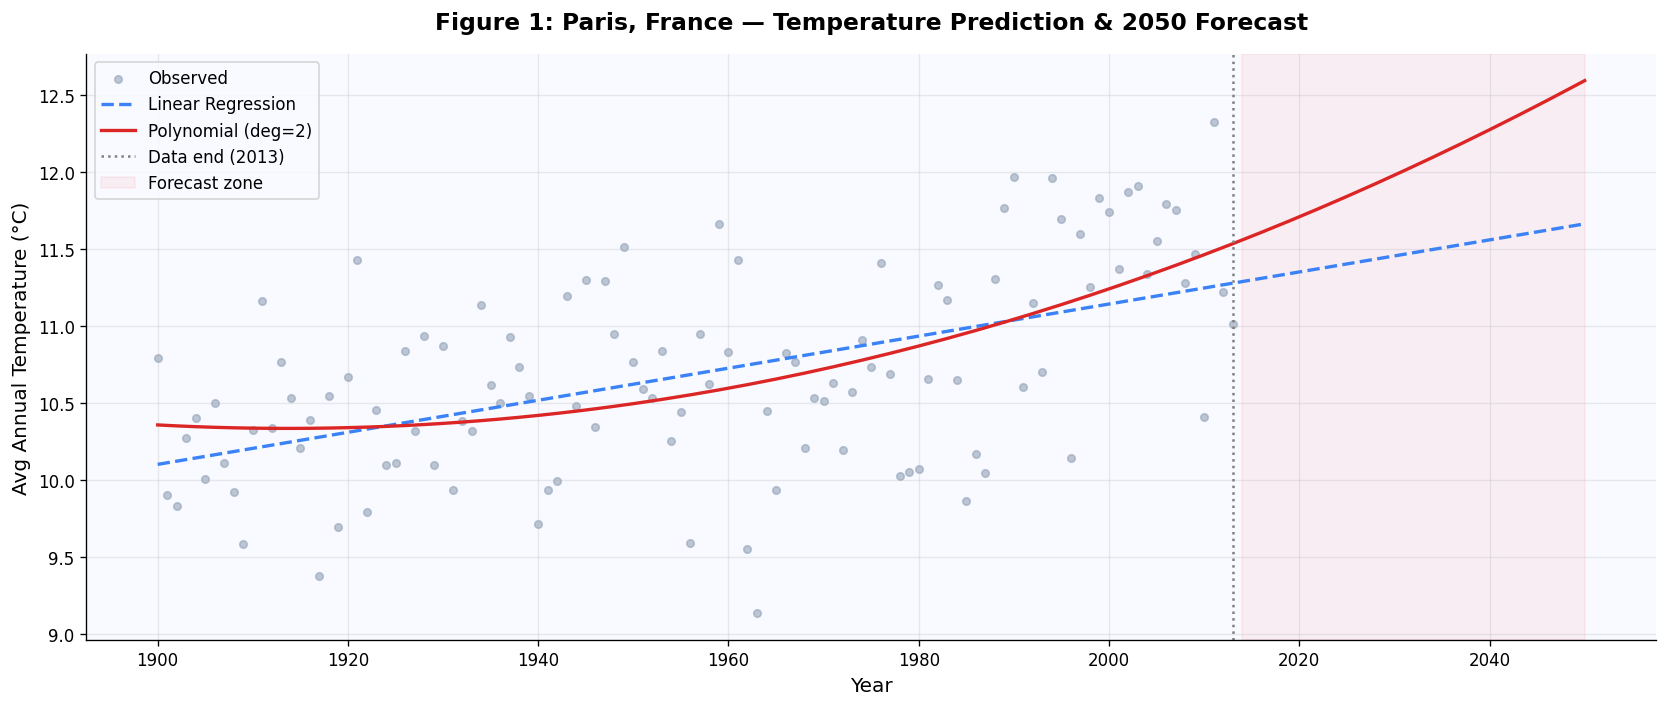

Fig 1 saved.


In [35]:
# ── Figure 1: Regression — Paris with forecast to 2050 ───────────────────────
city_key = ('Paris', 'France')
sub = city_yr[
    (city_yr['City']==city_key[0]) & (city_yr['Country']==city_key[1]) &
    (city_yr['Year'] >= 1900)
].dropna()
X_f = sub[['Year']]
y_f = sub['Avg_Temp_C']

lin_m  = LinearRegression().fit(X_f, y_f)
poly_m = Pipeline([('poly',PolynomialFeatures(2,include_bias=False)),('reg',LinearRegression())]).fit(X_f,y_f)

future_yrs = pd.DataFrame({'Year': np.arange(1900, 2051)})

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(sub['Year'], sub['Avg_Temp_C'], color='#94A3B8', s=20, alpha=0.6, label='Observed')
ax.plot(future_yrs['Year'], lin_m.predict(future_yrs),  color='#3B82F6', linewidth=2, linestyle='--', label='Linear Regression')
ax.plot(future_yrs['Year'], poly_m.predict(future_yrs), color='#DC2626', linewidth=2, label='Polynomial (deg=2)')
ax.axvline(2013, color='gray', linestyle=':', linewidth=1.5, label='Data end (2013)')
ax.axvspan(2014, 2050, alpha=0.05, color='red', label='Forecast zone')
ax.set_title('Figure 1: Paris, France — Temperature Prediction & 2050 Forecast', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Annual Temperature (°C)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(EXPORT_DIR + 'fig_regression_paris.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved.')

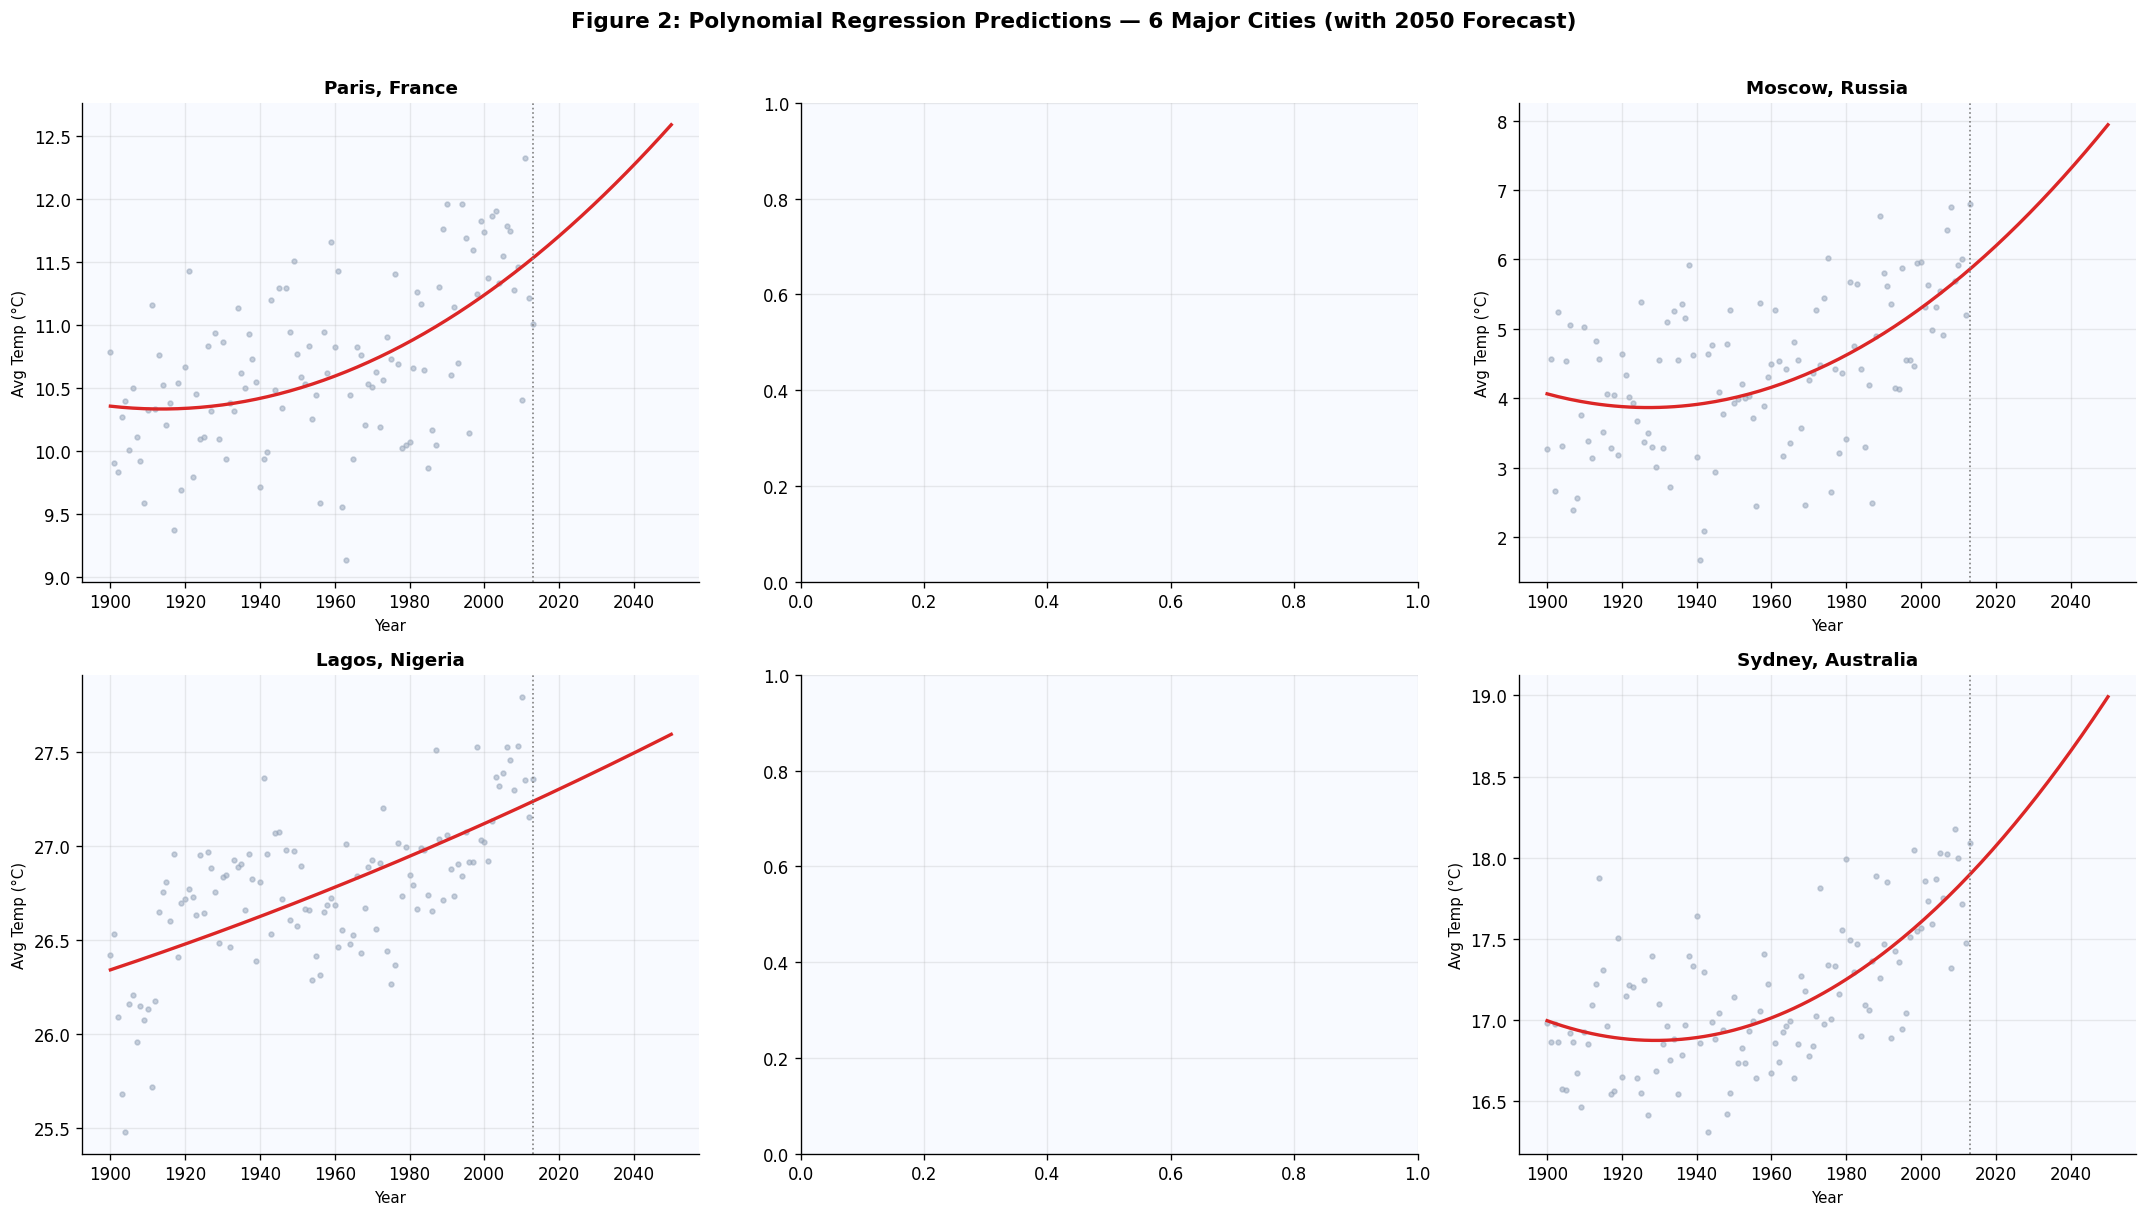

Fig 2 saved.


In [36]:
# ── Figure 2: Multi-city regression predictions ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
future = pd.DataFrame({'Year': np.arange(1900, 2051)})

for i, (city, country) in enumerate(SAMPLE_CITIES):
    sub = city_yr[
        (city_yr['City']==city) & (city_yr['Country']==country) &
        (city_yr['Year'] >= 1900)
    ].dropna()
    if len(sub) < 20: continue

    X_s = sub[['Year']]
    y_s = sub['Avg_Temp_C']
    m   = Pipeline([('poly',PolynomialFeatures(2,include_bias=False)),('reg',LinearRegression())]).fit(X_s,y_s)

    ax = axes[i]
    ax.scatter(sub['Year'], sub['Avg_Temp_C'], s=8, alpha=0.5, color='#94A3B8')
    ax.plot(future['Year'], m.predict(future), color='#DC2626', linewidth=2)
    ax.axvline(2013, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{city}, {country}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Avg Temp (°C)', fontsize=9)

plt.suptitle('Figure 2: Polynomial Regression Predictions — 6 Major Cities (with 2050 Forecast)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EXPORT_DIR + 'fig_regression_multi_city.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved.')

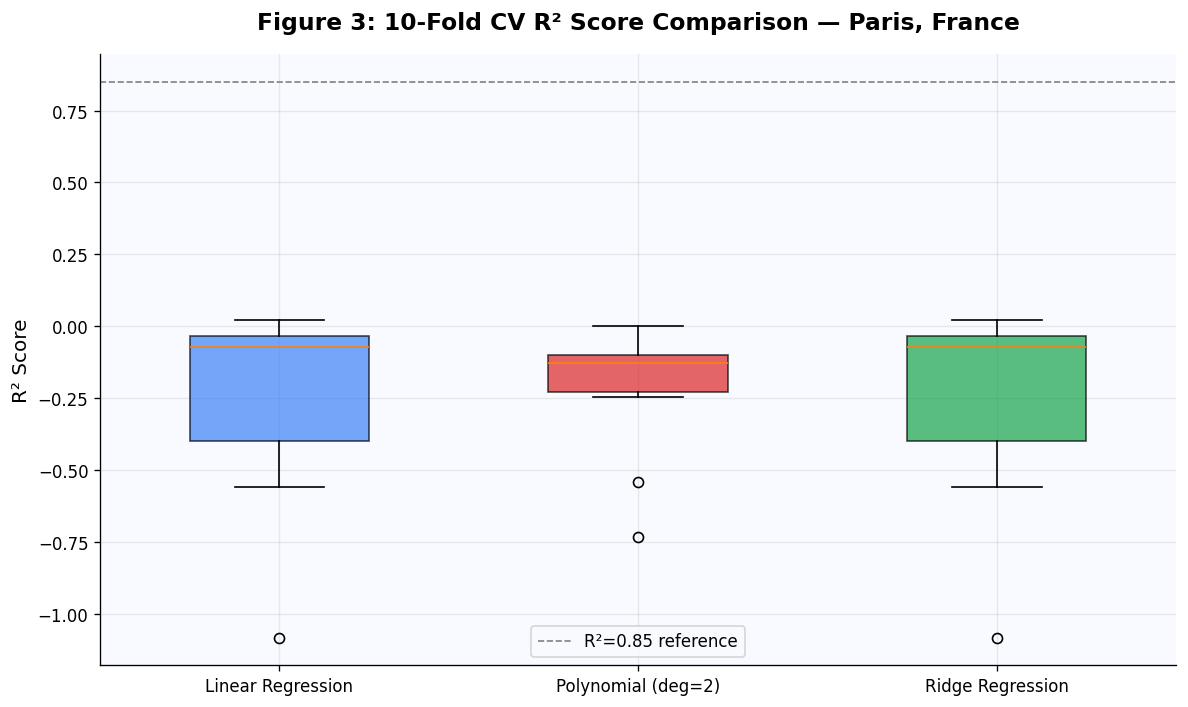

Fig 3 saved.


In [37]:
# ── Figure 3: CV Score Comparison (Linear vs Poly vs Ridge) ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))
all_scores = {
    'Linear Regression':   linear_scores,
    'Polynomial (deg=2)':  poly_scores,
    'Ridge Regression':    ridge_scores,
}
colors = ['#3B82F6', '#DC2626', '#16A34A']
bp = ax.boxplot(list(all_scores.values()), labels=list(all_scores.keys()),
                patch_artist=True, notch=False, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Figure 3: 10-Fold CV R² Score Comparison — Paris, France', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('R² Score', fontsize=12)
ax.axhline(0.85, color='gray', linestyle='--', linewidth=1, label='R²=0.85 reference')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(EXPORT_DIR + 'fig_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved.')

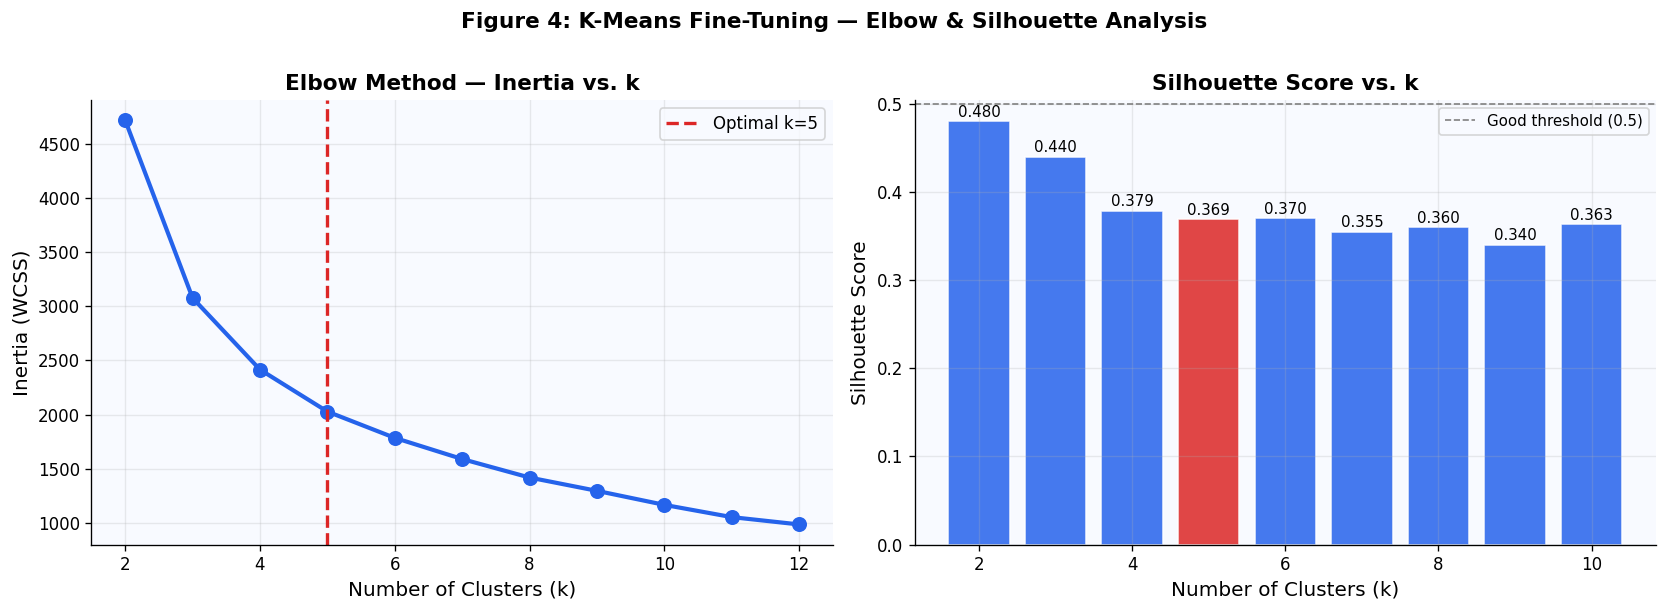

Fig 4 saved.


In [38]:
# ── Figure 4: Elbow + Silhouette ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax = axes[0]
ax.plot(list(k_range), inertias, 'o-', color='#2563EB', linewidth=2.5, markersize=8)
ax.axvline(5, color='#DC2626', linestyle='--', linewidth=2, label='Optimal k=5')
ax.set_title('Elbow Method — Inertia vs. k', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (WCSS)', fontsize=12)
ax.legend(fontsize=10)

# Silhouette
ax2 = axes[1]
ks   = list(sil_scores.keys())
vals = list(sil_scores.values())
colors_sil = ['#DC2626' if k==5 else '#2563EB' for k in ks]
ax2.bar(ks, vals, color=colors_sil, alpha=0.85, edgecolor='white')
for k, v in zip(ks, vals):
    ax2.text(k, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
ax2.set_title('Silhouette Score vs. k', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Good threshold (0.5)')
ax2.legend(fontsize=9)

plt.suptitle('Figure 4: K-Means Fine-Tuning — Elbow & Silhouette Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EXPORT_DIR + 'fig_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved.')

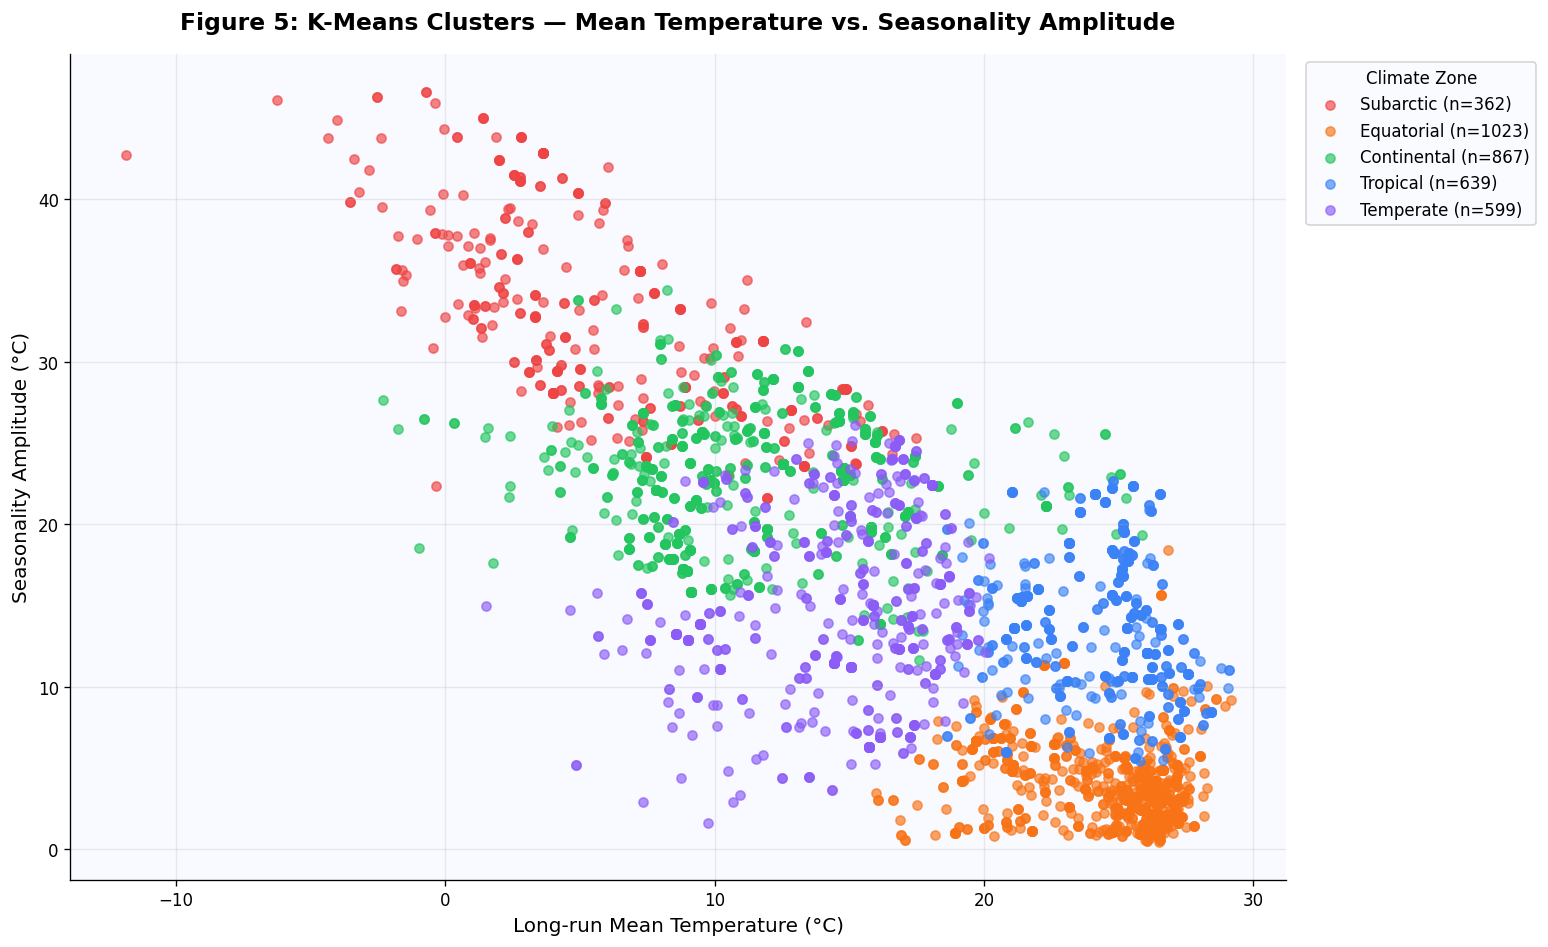

Fig 5 saved.


In [39]:
# ── Figure 5: K-Means Scatter — Mean Temp vs Seasonality ─────────────────────
CLUSTER_COLORS = {0:'#EF4444',1:'#F97316',2:'#22C55E',3:'#3B82F6',4:'#8B5CF6'}

fig, ax = plt.subplots(figsize=(13, 8))
for cl in sorted(city_profiles['Cluster'].unique()):
    sub = city_profiles[city_profiles['Cluster']==cl]
    zone = label_map.get(cl, f'Cluster {cl}')
    ax.scatter(sub['Mean_Temp'], sub['Seasonality'],
               color=CLUSTER_COLORS[cl], s=30, alpha=0.65, label=f'{zone} (n={len(sub)})')

ax.set_title('Figure 5: K-Means Clusters — Mean Temperature vs. Seasonality Amplitude', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Long-run Mean Temperature (°C)', fontsize=12)
ax.set_ylabel('Seasonality Amplitude (°C)', fontsize=12)
ax.legend(title='Climate Zone', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig(EXPORT_DIR + 'fig_kmeans_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 saved.')

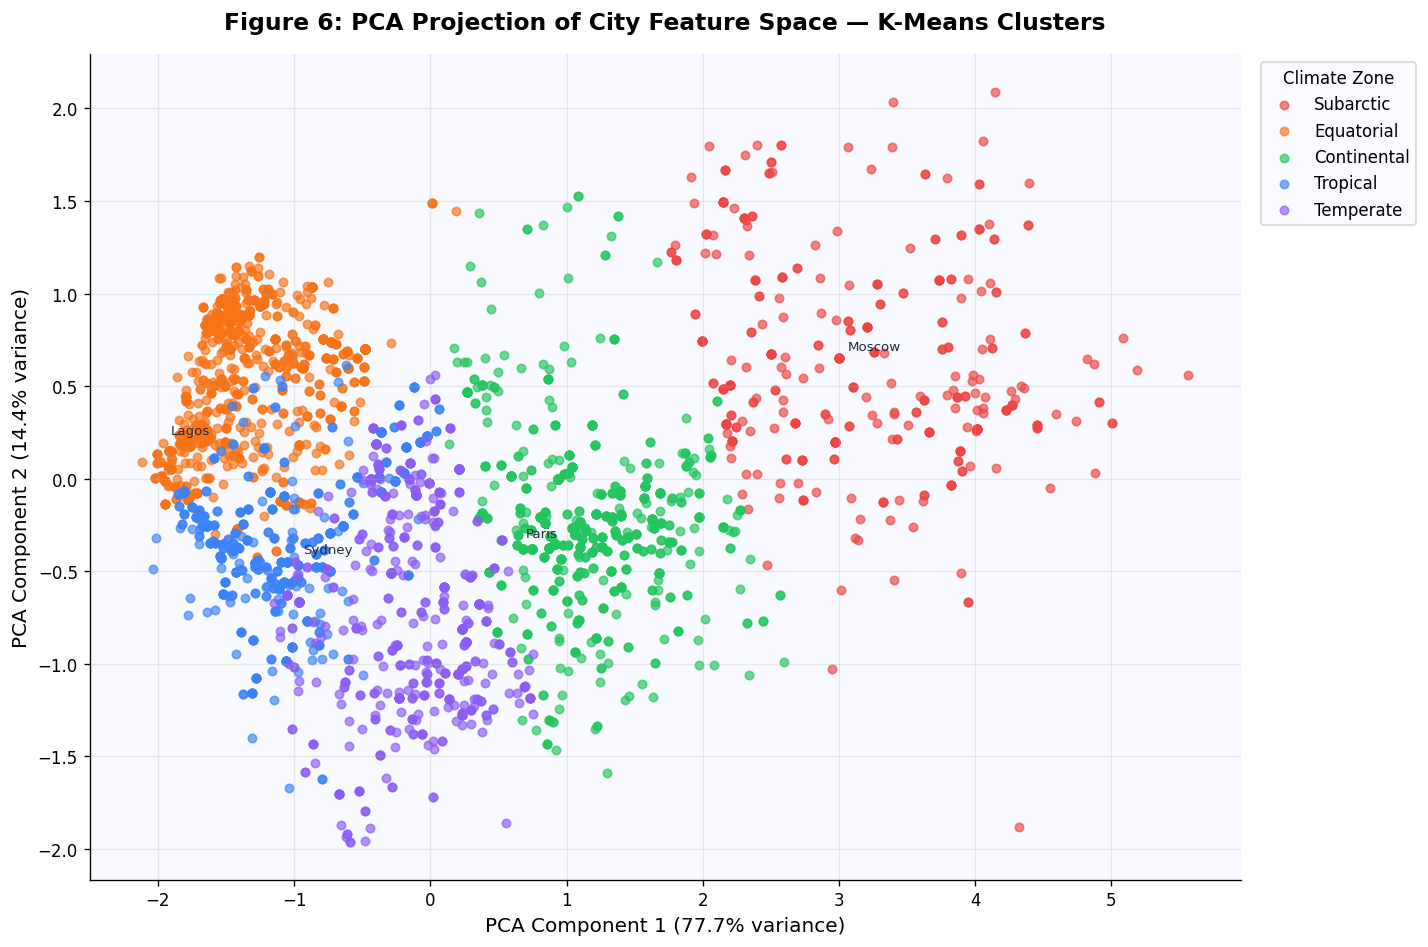

Fig 6 saved.


In [40]:
# ── Figure 6: PCA 2D projection of clusters ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
for cl in sorted(city_profiles['Cluster'].unique()):
    sub  = city_profiles[city_profiles['Cluster']==cl]
    zone = label_map.get(cl, f'Cluster {cl}')
    ax.scatter(sub['PCA1'], sub['PCA2'],
               color=CLUSTER_COLORS[cl], s=25, alpha=0.65, label=f'{zone}')

# Annotate a few well-known cities
known = ['Paris','Mumbai','Moscow','Lagos','Sydney','Yakutsk']
for _, row in city_profiles[city_profiles['City'].isin(known)].iterrows():
    ax.annotate(row['City'], (row['PCA1'], row['PCA2']),
                fontsize=8, color='#1E293B',
                xytext=(5,5), textcoords='offset points')

ax.set_title('Figure 6: PCA Projection of City Feature Space — K-Means Clusters', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.legend(title='Climate Zone', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig(EXPORT_DIR + 'fig_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 saved.')

## 8. Model Summary & Export <a id='8'></a>

In [21]:
print('=' * 60)
print('  ALGORITHM SUMMARY')
print('=' * 60)
print()
print('LINEAR REGRESSION (Prediction):')
for city, m in results.items():
    best = best_models.get(city, 'Linear')
    print(f'  {city:<30} R2={m["R2"]:.3f}  CV_R2={m["CV_R2"]:.3f}  Best: {best}')
print()
print('K-MEANS CLUSTERING (k=5):')
print(f'  Silhouette Score: {sil:.4f}')
print(f'  Inertia:          {iner:.2f}')
print(f'  PCA variance:     {pca.explained_variance_ratio_.sum():.1%} (2 components)')
print()
print('Cluster sizes:')
for cl in sorted(city_profiles['Cluster'].unique()):
    n    = len(city_profiles[city_profiles['Cluster']==cl])
    zone = label_map.get(cl,'?')
    print(f'  Cluster {cl} [{zone}]: {n} cities')

  ALGORITHM SUMMARY

LINEAR REGRESSION (Prediction):
  Paris, France                  R2=-1.237  CV_R2=-0.391  Best: Ridge
  Moscow, Russia                 R2=-2.638  CV_R2=-0.334  Best: Poly
  Lagos, Nigeria                 R2=-1.681  CV_R2=-0.744  Best: Linear
  Sydney, Australia              R2=-3.270  CV_R2=-0.724  Best: Poly

K-MEANS CLUSTERING (k=5):
  Silhouette Score: 0.3691
  Inertia:          2027.80
  PCA variance:     92.1% (2 components)

Cluster sizes:
  Cluster 0 [Subarctic]: 362 cities
  Cluster 1 [Equatorial]: 1023 cities
  Cluster 2 [Continental]: 867 cities
  Cluster 3 [Tropical]: 639 cities
  Cluster 4 [Temperate]: 599 cities


In [22]:
# ── Export city profiles with cluster labels ──────────────────────────────────
export_path = EXPORT_DIR + 'city_profiles_clustered.csv'
city_profiles.to_csv(export_path, index=False)

print(f'✅ Exported: city_profiles_clustered.csv')
print(f'   Shape: {city_profiles.shape}')
print(f'   Columns: {city_profiles.columns.tolist()}')
print()
print('All figures saved to Google Drive:')
for fig_name in ['fig_regression_paris.png','fig_regression_multi_city.png',
                  'fig_cv_scores.png','fig_elbow_silhouette.png',
                  'fig_kmeans_scatter.png','fig_kmeans_pca.png']:
    print(f'  ✅ {fig_name}')

✅ Exported: city_profiles_clustered.csv
   Shape: (3490, 9)
   Columns: ['City', 'Country', 'Mean_Temp', 'Seasonality', 'Warming_Rate', 'Cluster', 'Climate_Zone', 'PCA1', 'PCA2']

All figures saved to Google Drive:
  ✅ fig_regression_paris.png
  ✅ fig_regression_multi_city.png
  ✅ fig_cv_scores.png
  ✅ fig_elbow_silhouette.png
  ✅ fig_kmeans_scatter.png
  ✅ fig_kmeans_pca.png
